# Calidad de Vinos

### 1. Análisis.

* Análisis de las carácteristicas y calidad de producción de vino.
* El nombre del archivo es `winequality-red.csv`.
* Estas con las caracteristicas a del vino. `fixed acidity	volatile acidity	citric acid	residual sugar	chlorides	free sulfur dioxide	total sulfur dioxide	density	pH	sulphates	alcohol	quality`.
* Supongo que el target de este modelo será `quality`.

***NOTAS***
* `{df.shape[0]}`: puede ser clave para ver la cantidad de registros, `{df.shape[1]}` para ver todas las variables objetivos.

In [5]:
import pandas as pd
import numpy as np

### Transformamos el archivo en dataframe
df = pd.read_csv('winequality-red.csv')

### Mostramos los primeros datos de nuestro df.
df.head()

### Podemos ver alguna información del dataframe
print(f'Dataset --> [Filas: {df.shape[0]}], [Columnas: {df.shape[1]}]')
print("\n")

### Ver atributos del df (variabilidad, promedios etc)
print("\n Resumen del Dataset:\n", df.info())
print("\n")

### Revisar si hay valores faltantes 
print("\n Valores Null: ", df.isnull().sum())
print("\n")
#df.describe()

Dataset --> [Filas: 1599], [Columnas: 12]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB

 Resumen del Dataset:
 None



 Valores Null:  fixed acidity           0
volatile

### 2. Visualización de informacion

* Queremos ver cuantos vinos corresponden a cada diferente categoría, esto ya que no sabemos la escala con la que se rigen.
* Despues de ver la gráfica podemos ver como hay rangos 3-8 en calidades de vino.
***NOTAS***
* `sns.countplot()`: crea un gráfico de barras que muestra el conteo de observaciones por categoría.
* `hue='quality'`: agrupar por calidad del vino.
* `plt.figure()`: crea una nueva figura y define sus dimensiones

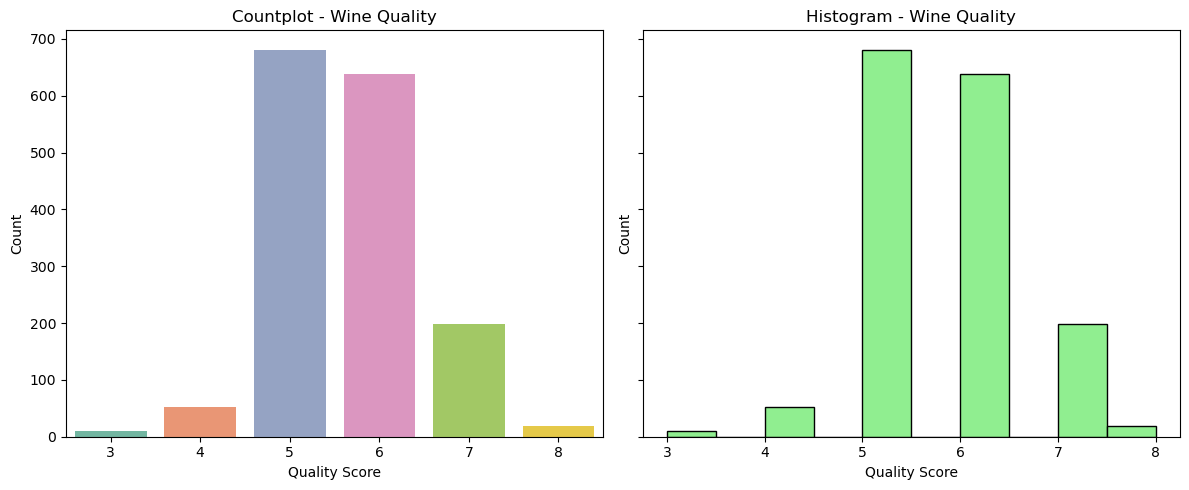

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

### Crear figura con 2 subgráficas (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)  # sharey=True para que compartan el eje Y

### Gráfico 1: Countplot con seaborn
sns.countplot(
    x='quality',
    data=df,
    hue='quality',
    palette='Set2',
    legend=False,
    ax=axes[0]  # Aquí se especifica en qué subplot dibujar
)
axes[0].set_title('Countplot - Wine Quality')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Count')

### Gráfico 2: Histograma con matplotlib
axes[1].hist(df['quality'], color="lightgreen", edgecolor="black")
axes[1].set_title('Histogram - Wine Quality')
axes[1].set_xlabel('Quality Score')
axes[1].set_ylabel('Count')

### Ajustar el espacio entre subplots
plt.tight_layout()

### Mostrar ambas gráficas
plt.show()

### 3. Matriz de correlacion.

* Es necesario revisar la relación entre las variables, de una con otra.
* `df.corr()` calcula los coeficientes de correlación entre todas las variables numéricas del DataFrame
* Recordemos que la matriz de covarianza no es lo mismo que la de correlación, la covarianza es parte del calculo de correlaciones.
* No hay relaciones muy fuertes entre las variables.

***NOTAS***
* `plt.figure(figsize=(10, 8))` : 10 pulgadas de ancho × 8 pulgadas de alto.
* `# sns.heatmap()`: genera una visualización tipo mapa de calor para la matriz de correlación.

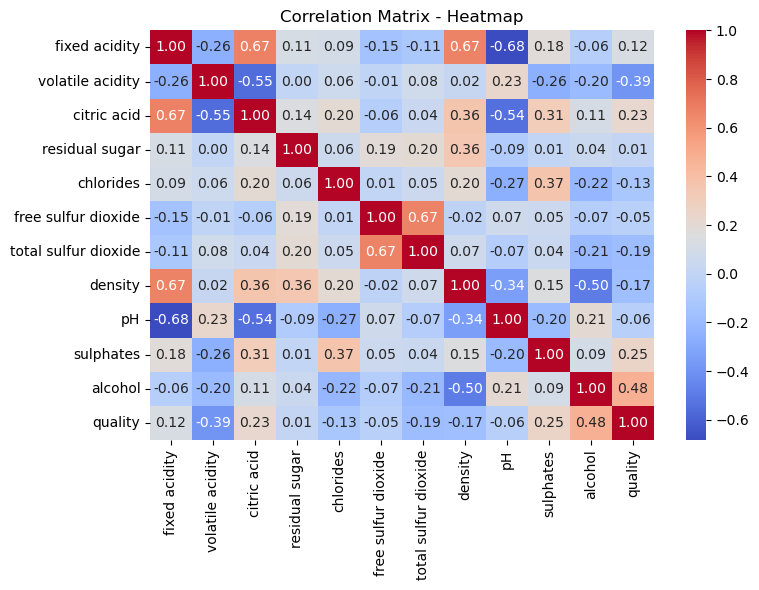

In [16]:
# CÁLCULO DE LA MATRIZ DE CORRELACIÓN
correlation = df.corr()

# === GRÁFICO 1: Heatmap con seaborn ===
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title('Correlation Matrix - Heatmap')
plt.tight_layout()
plt.show()

# # === GRÁFICO 2: Matshow con matplotlib ===
# plt.figure(figsize=(8, 6))
# plt.matshow(correlation, cmap="bwr", vmin=-1, vmax=1, fignum=1)  # fignum=1 para usar la figura activa
# plt.title("Correlation Matrix - Matshow", y=1.15)

# # Agregar etiquetas
# plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
# plt.yticks(range(len(correlation.index)), correlation.index)

# # Barra de color
# plt.colorbar()
# plt.show()

# # === ANÁLISIS DE CORRELACIONES CON 'quality' ===
# correlation['quality'].sort_values(ascending=False)

### 3. Análisis de la información

* La correlacion entre la calidad y el nivel de alcohol es el más grande positivo. Esto significa que el aumento en el nivel de alcohol de un vino está directamente relacionado a la calidad del mismo.
* Por otro lado, la correlacion entre la acidéz y la calidad es el mayor negativo. Por lo tanto, la reducción en el nivel de acidéz en un vino está relacionado con una mayor caliad del vino.
* Hay que graficar estas variables.
* Los gráficos tiene muchos `data outliers` .

***NOTAS***
* `sns.boxplot()`: crea un diagrama de caja (boxplot) para visualizar la distribución de una variable numérica por categorías

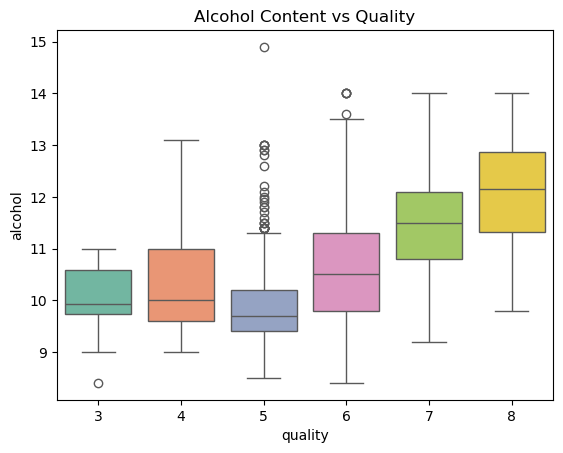

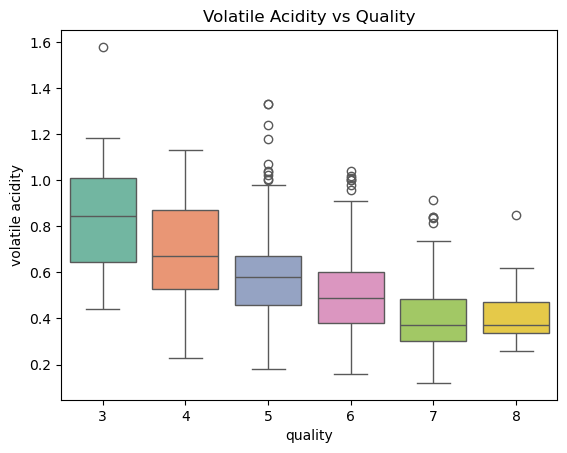

In [17]:
# EJEMPLO 1: RELACIÓN ENTRE ALCOHOL Y CALIDAD
sns.boxplot(
    x='quality',           # Variable categórica en el eje X (niveles de calidad)
    y='alcohol',           # Variable numérica en el eje Y (contenido de alcohol)
    data=df,               # DataFrame que contiene los datos
    hue='quality',         # Agrupa/colorea por la misma variable de calidad
    palette='Set2',        # Usa la paleta de colores 'Set2'
    legend=False           # Oculta la leyenda (redundante)
)

# Personalización del primer gráfico
plt.title('Alcohol Content vs Quality')  # Título descriptivo
plt.show()                               # Muestra el gráfico

# EJEMPLO 2: RELACIÓN ENTRE ACIDEZ VOLÁTIL Y CALIDAD
sns.boxplot(
    x='quality',               # Variable categórica en el eje X (calidad)
    y='volatile acidity',      # Variable numérica en el eje Y (acidez volátil)
    data=df,                   # DataFrame con los datos
    hue='quality',             # Agrupa por calidad
    palette='Set2',            # Misma paleta de colores para consistencia
    legend=False               # Oculta la leyenda
)

# Personalización del segundo gráfico
plt.title('Volatile Acidity vs Quality')  # Título específico para este análisis
plt.show()                                # Muestra el segundo gráfico